# MovieLens

In [5]:
import pandas as pd

In [6]:
movies = pd.read_csv('data/movies.csv')
movies

,movieId,title,genres
0,1,Toy Story (1995),Adventure|Animation|Children|Comedy|Fantasy
1,2,Jumanji (1995),Adventure|Children|Fantasy
2,3,Grumpier Old Men (1995),Comedy|Romance
3,4,Waiting to Exhale (1995),Comedy|Drama|Romance
4,5,Father of the Bride Part II (1995),Comedy
...,...,...,...
9737,193581,Black Butler: Book of the Atlantic (2017),Action|Animation|Comedy|Fantasy
9738,193583,No Game No Life: Zero (2017),Animation|Comedy|Fantasy
9739,193585,Flint (2017),Drama
9740,193587,Bungo Stray Dogs: Dead Apple (2018),Action|Animation


In [7]:
ratings = pd.read_csv('data/ratings.csv')
ratings

,userId,movieId,rating,timestamp
0,1,1,4.0,964982703
1,1,3,4.0,964981247
2,1,6,4.0,964982224
3,1,47,5.0,964983815
4,1,50,5.0,964982931
...,...,...,...,...
100831,610,166534,4.0,1493848402
100832,610,168248,5.0,1493850091
100833,610,168250,5.0,1494273047
100834,610,168252,5.0,1493846352


In [8]:
links = pd.read_csv('data/links.csv')
links

,movieId,imdbId,tmdbId
0,1,114709,862.0
1,2,113497,8844.0
2,3,113228,15602.0
3,4,114885,31357.0
4,5,113041,11862.0
...,...,...,...
9737,193581,5476944,432131.0
9738,193583,5914996,445030.0
9739,193585,6397426,479308.0
9740,193587,8391976,483455.0


In [9]:
tags = pd.read_csv('data/tags.csv')
tags

,userId,movieId,tag,timestamp
0,2,60756,funny,1445714994
1,2,60756,Highly quotable,1445714996
2,2,60756,will ferrell,1445714992
3,2,89774,Boxing story,1445715207
4,2,89774,MMA,1445715200
...,...,...,...,...
3678,606,7382,for katie,1171234019
3679,606,7936,austere,1173392334
3680,610,3265,gun fu,1493843984
3681,610,3265,heroic bloodshed,1493843978


# EDA

In [10]:
movies.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9742 entries, 0 to 9741
Data columns (total 3 columns):
 #   Column   Non-Null Count  Dtype 
---  ------   --------------  ----- 
 0   movieId  9742 non-null   int64 
 1   title    9742 non-null   object
 2   genres   9742 non-null   object
dtypes: int64(1), object(2)
memory usage: 228.5+ KB


In [11]:
ratings.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 100836 entries, 0 to 100835
Data columns (total 4 columns):
 #   Column     Non-Null Count   Dtype  
---  ------     --------------   -----  
 0   userId     100836 non-null  int64  
 1   movieId    100836 non-null  int64  
 2   rating     100836 non-null  float64
 3   timestamp  100836 non-null  int64  
dtypes: float64(1), int64(3)
memory usage: 3.1 MB


In [12]:
links.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9742 entries, 0 to 9741
Data columns (total 3 columns):
 #   Column   Non-Null Count  Dtype  
---  ------   --------------  -----  
 0   movieId  9742 non-null   int64  
 1   imdbId   9742 non-null   int64  
 2   tmdbId   9734 non-null   float64
dtypes: float64(1), int64(2)
memory usage: 228.5 KB


In [14]:
ratings.describe()

,userId,movieId,rating,timestamp
count,100836.000000,100836.000000,100836.000000,1.008360e+05
mean,326.127564,19435.295718,3.501557,1.205946e+09
std,182.618491,35530.987199,1.042529,2.162610e+08
min,1.000000,1.000000,0.500000,8.281246e+08
25%,177.000000,1199.000000,3.000000,1.019124e+09
50%,325.000000,2991.000000,3.500000,1.186087e+09
75%,477.000000,8122.000000,4.000000,1.435994e+09
max,610.000000,193609.000000,5.000000,1.537799e+09


array([[<Axes: title={'center': 'userId'}>,
        <Axes: title={'center': 'movieId'}>],
       [<Axes: title={'center': 'rating'}>,
        <Axes: title={'center': 'timestamp'}>]], dtype=object)

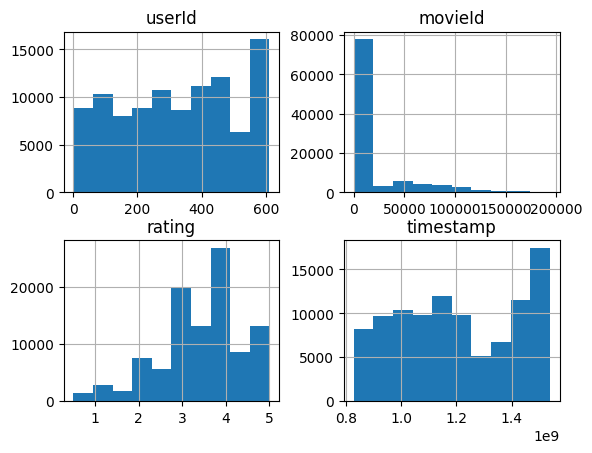

In [17]:
ratings.hist()

## Preguntas sobre los datasets

- Cuál es el top 5 de películas mejor rankeadas en promedio?

In [19]:
df = ratings.merge(movies, on="movieId")

In [22]:
movie_ratings = (df.groupby(["movieId", "title"]).agg(avg_rating=("rating", "mean"), count=("rating", "count")).reset_index())
top5_movies = movie_ratings.sort_values("avg_rating", ascending=False).head(5)

print("Top 5 películas mejor rankeadas:")
print(top5_movies)

Top 5 películas mejor rankeadas:
      movieId                             title  avg_rating  count
9693   187717  Won't You Be My Neighbor? (2018)         5.0      1
4667     6983                  Jane Eyre (1944)         5.0      1
3802     5328                       Rain (2001)         5.0      1
7927    95843            Goodbye Charlie (1964)         5.0      1
2934     3941    Sorority House Massacre (1986)         5.0      1


- Cuál es el género con más revies?

In [25]:
df = ratings.merge(movies, on="movieId")
df = df.assign(genres=df["genres"].str.split("|")).explode("genres")
genero = (df.groupby("genres")["rating"].count().reset_index(name="num_reviews").sort_values("num_reviews", ascending=False))
print("Género con más reviews:")
print(genero.head(1))

Género con más reviews:
  genres  num_reviews
8  Drama        41928


- Cuál es el usuario con más críticas y cuál es su género favorito?

In [27]:
df = ratings.merge(movies, on="movieId")
df = df.assign(genres=df["genres"].str.split("|")).explode("genres")

user_counts = (df.groupby("userId")["rating"].count().reset_index(name="num_reviews").sort_values("num_reviews", ascending=False))

top_user = user_counts.iloc[0]["userId"]
print(f"Usuario con más críticas: {top_user}")
print(f"Número de críticas: {user_counts.iloc[0]['num_reviews']}")

# Género favorito del usuario
user_genres = (df[df["userId"] == top_user].groupby("genres")["rating"].count().reset_index(name="num_reviews").sort_values("num_reviews", ascending=False))

print(f"Género favorito del usuario {top_user}:")
print(user_genres.head(1))


Usuario con más críticas: 414
Número de críticas: 6616
Género favorito del usuario 414:
  genres  num_reviews
8  Drama         1309
